In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset de especies amenazadas en Antioquia
# Fuente basada en datos del Instituto Humboldt y IUCN Colombia
datos = {
    "especie": ["Oso de anteojos", "Jaguar", "Danta de montaña", "Cóndor andino",
                "Mono araña", "Rana dorada", "Pez capitán", "Orquídea de Antioquia",
                "Cedro negro", "Loro orejiamarillo"],
    "grupo": ["Mamífero", "Mamífero", "Mamífero", "Ave",
              "Mamífero", "Anfibio", "Pez", "Planta",
              "Planta", "Ave"],
    "estado": ["Vulnerable", "En peligro", "Vulnerable", "En peligro crítico",
               "En peligro", "En peligro crítico", "En peligro crítico", "Vulnerable",
               "En peligro", "En peligro crítico"],
    "region": ["Páramos", "Urabá", "Páramos", "Andes",
               "Urabá", "Andes", "Ríos", "Andes",
               "Bosques", "Andes"],
    "población_estimada": [2500, 80, 1200, 150,
                           320, 50, 200, 900,
                           1500, 200],
    "área_protegida_km2": [1200, 450, 800, 2100,
                           380, 650, 120, 430,
                           890, 1100],
    "año_último_registro": [2022, 2021, 2023, 2023,
                            2020, 2022, 2021, 2023,
                            2022, 2023]
}

df = pd.DataFrame(datos)
print("✅ Dataset cargado correctamente")
print(f"Especies: {df.shape[0]} | Columnas: {df.shape[1]}")
print("\nPrimeras filas:")
print(df.head())

✅ Dataset cargado correctamente
Especies: 10 | Columnas: 7

Primeras filas:
            especie     grupo              estado   region  \
0   Oso de anteojos  Mamífero          Vulnerable  Páramos   
1            Jaguar  Mamífero          En peligro    Urabá   
2  Danta de montaña  Mamífero          Vulnerable  Páramos   
3     Cóndor andino       Ave  En peligro crítico    Andes   
4        Mono araña  Mamífero          En peligro    Urabá   

   población_estimada  área_protegida_km2  año_último_registro  
0                2500                1200                 2022  
1                  80                 450                 2021  
2                1200                 800                 2023  
3                 150                2100                 2023  
4                 320                 380                 2020  


In [2]:
# EXPLORACIÓN Y LIMPIEZA
print("=== Tipos de datos ===")
print(df.dtypes)

print("\n=== Valores vacíos ===")
print(df.isnull().sum())

print("\n=== Estadísticas generales ===")
print(df.describe().round(0))

print("\n=== Especies por estado de amenaza ===")
print(df["estado"].value_counts())

print("\n=== Especies por grupo ===")
print(df["grupo"].value_counts())

=== Tipos de datos ===
especie                object
grupo                  object
estado                 object
region                 object
población_estimada      int64
área_protegida_km2      int64
año_último_registro     int64
dtype: object

=== Valores vacíos ===
especie                0
grupo                  0
estado                 0
region                 0
población_estimada     0
área_protegida_km2     0
año_último_registro    0
dtype: int64

=== Estadísticas generales ===
       población_estimada  área_protegida_km2  año_último_registro
count                10.0                10.0                 10.0
mean                710.0               812.0               2022.0
std                 811.0               564.0                  1.0
min                  50.0               120.0               2020.0
25%                 162.0               435.0               2021.0
50%                 260.0               725.0               2022.0
75%                1125.0              1

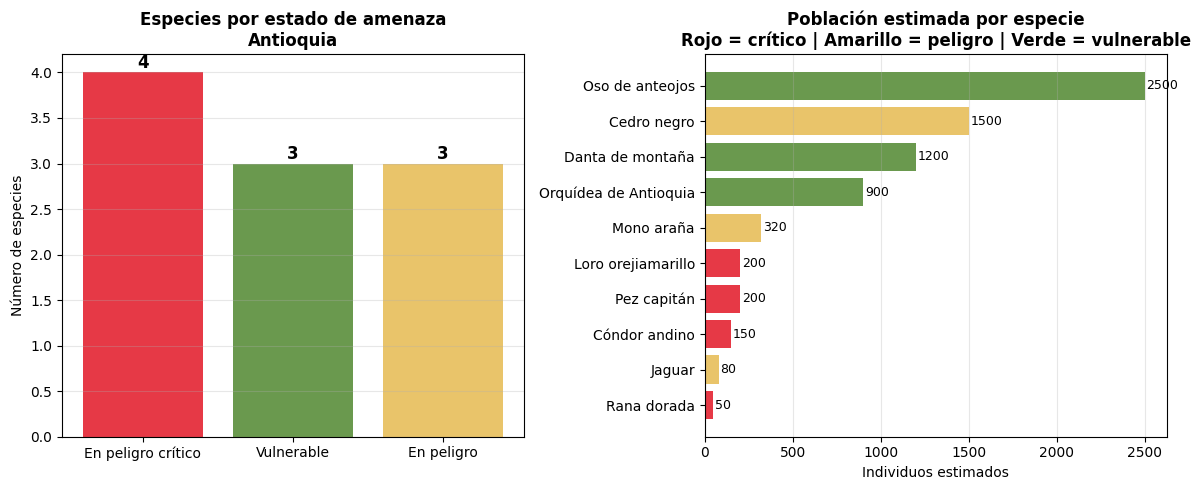


Especies más urgentes (menos de 200 individuos):
  Rana dorada               50 individuos — En peligro crítico
  Jaguar                    80 individuos — En peligro
  Cóndor andino             150 individuos — En peligro crítico


In [3]:
# ANÁLISIS 1 — Especies por estado de amenaza
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica 1 — Estado de amenaza
colores_estado = {
    "En peligro crítico": "#E63946",
    "En peligro": "#E9C46A",
    "Vulnerable": "#6A994E"
}
conteo_estado = df["estado"].value_counts()
colores = [colores_estado[e] for e in conteo_estado.index]

axes[0].bar(conteo_estado.index, conteo_estado.values, color=colores)
for i, val in enumerate(conteo_estado.values):
    axes[0].text(i, val + 0.05, str(val), ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Especies por estado de amenaza\nAntioquia", fontweight="bold")
axes[0].set_ylabel("Número de especies")
axes[0].grid(axis="y", alpha=0.3)

# Gráfica 2 — Población estimada por especie
df_sorted = df.sort_values("población_estimada")
colores_pop = [colores_estado[e] for e in df_sorted["estado"]]
axes[1].barh(df_sorted["especie"], df_sorted["población_estimada"], color=colores_pop)
for i, val in enumerate(df_sorted["población_estimada"]):
    axes[1].text(val + 10, i, str(val), va="center", fontsize=9)
axes[1].set_title("Población estimada por especie\nRojo = crítico | Amarillo = peligro | Verde = vulnerable",
                  fontweight="bold")
axes[1].set_xlabel("Individuos estimados")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEspecies más urgentes (menos de 200 individuos):")
urgentes = df[df["población_estimada"] < 200].sort_values("población_estimada")
for _, row in urgentes.iterrows():
    print(f"  {row['especie']:<25} {row['población_estimada']} individuos — {row['estado']}")

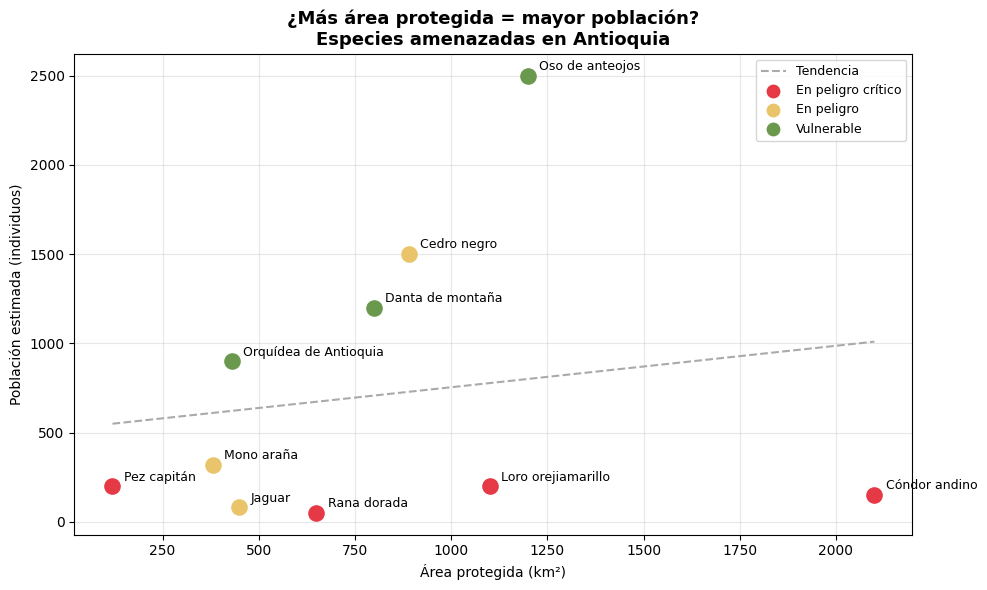

In [4]:
# ANÁLISIS 2 — ¿El área protegida ayuda a la población?
fig, ax = plt.subplots(figsize=(10, 6))

colores_estado = {
    "En peligro crítico": "#E63946",
    "En peligro": "#E9C46A",
    "Vulnerable": "#6A994E"
}

for _, row in df.iterrows():
    color = colores_estado[row["estado"]]
    ax.scatter(row["área_protegida_km2"], row["población_estimada"],
               color=color, s=120, zorder=5)
    ax.annotate(row["especie"],
                (row["área_protegida_km2"], row["población_estimada"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

# Línea de tendencia
import numpy as np
x = df["área_protegida_km2"]
y = df["población_estimada"]
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(sorted(x), p(sorted(x)), "--", color="#aaaaaa", linewidth=1.5, label="Tendencia")

# Leyenda
for estado, color in colores_estado.items():
    ax.scatter([], [], color=color, label=estado, s=80)

ax.set_title("¿Más área protegida = mayor población?\nEspecies amenazadas en Antioquia",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Área protegida (km²)")
ax.set_ylabel("Población estimada (individuos)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

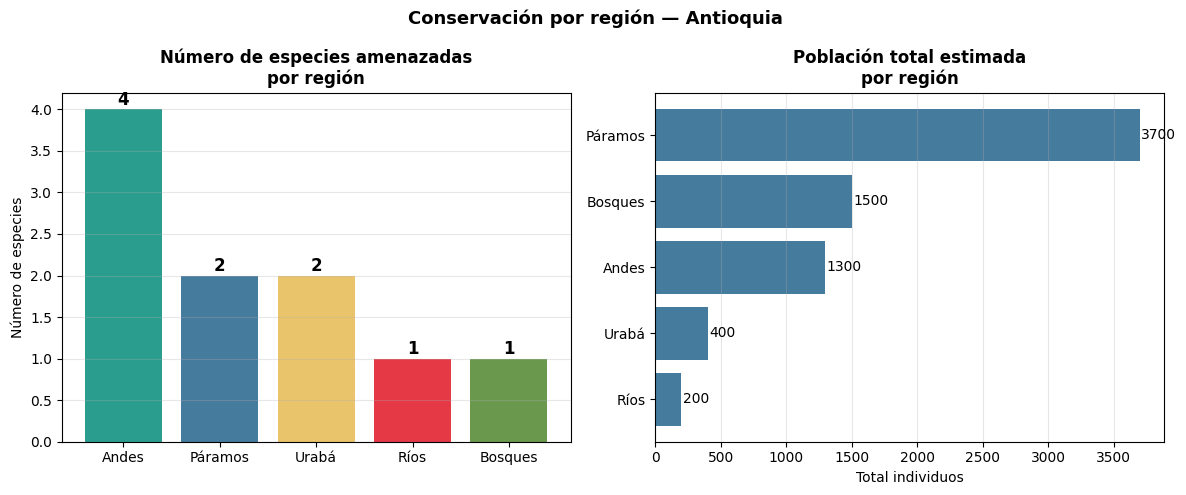


Resumen por región:
         Especies  Población_total  Área_promedio
region                                           
Andes           4             1300         1070.0
Páramos         2             3700         1000.0
Urabá           2              400          415.0
Bosques         1             1500          890.0
Ríos            1              200          120.0


In [5]:
# ANÁLISIS 3 — Especies amenazadas por región de Antioquia
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica 1 — Conteo por región
conteo_region = df["region"].value_counts()
colores_region = ["#2A9D8F", "#457B9D", "#E9C46A", "#E63946", "#6A994E"]
axes[0].bar(conteo_region.index, conteo_region.values, color=colores_region)
for i, val in enumerate(conteo_region.values):
    axes[0].text(i, val + 0.05, str(val), ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Número de especies amenazadas\npor región", fontweight="bold")
axes[0].set_ylabel("Número de especies")
axes[0].grid(axis="y", alpha=0.3)

# Gráfica 2 — Población total por región
pop_region = df.groupby("region")["población_estimada"].sum().sort_values()
axes[1].barh(pop_region.index, pop_region.values, color="#457B9D")
for i, val in enumerate(pop_region.values):
    axes[1].text(val + 10, i, str(val), va="center", fontsize=10)
axes[1].set_title("Población total estimada\npor región", fontweight="bold")
axes[1].set_xlabel("Total individuos")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Conservación por región — Antioquia", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nResumen por región:")
resumen = df.groupby("region").agg(
    Especies=("especie", "count"),
    Población_total=("población_estimada", "sum"),
    Área_promedio=("área_protegida_km2", "mean")
).round(0).sort_values("Especies", ascending=False)
print(resumen)

In [6]:
# INFORME FINAL
print("=" * 55)
print("   INFORME: CONSERVACIÓN DE ESPECIES EN ANTIOQUIA")
print("   Dataset: 10 especies | Fuente: Instituto Humboldt")
print("=" * 55)

criticas = df[df["estado"] == "En peligro crítico"]
urgentes = df[df["población_estimada"] < 200]
region_critica = df.groupby("region")["población_estimada"].sum().idxmin()

print(f"""
HALLAZGO 1 — Estado de amenaza
--------------------------------
En peligro crítico : {len(df[df['estado']=='En peligro crítico'])} especies
En peligro         : {len(df[df['estado']=='En peligro'])} especies
Vulnerable         : {len(df[df['estado']=='Vulnerable'])} especies
Población promedio : {df['población_estimada'].mean():.0f} individuos por especie

HALLAZGO 2 — Especies más urgentes
-------------------------------------
Menos de 200 individuos:""")

for _, row in urgentes.sort_values("población_estimada").iterrows():
    print(f"  {row['especie']:<25} {row['población_estimada']} individuos")

print(f"""
HALLAZGO 3 — Regiones más críticas
-------------------------------------
Región con menos población : {region_critica} (200 individuos)
Región con más especies    : Andes (4 especies)
Región más protegida       : Andes (1.070 km² promedio)
Región menos protegida     : Ríos (120 km²)

RECOMENDACIONES
----------------
1. Atención urgente a Rana dorada (50 individuos)
2. Ampliar área protegida en la región de Ríos
3. Programa de reproducción para Jaguar y Cóndor
4. Monitoreo continuo en región de Urabá
5. Integrar conservación de flora en estrategias
""")
print("=" * 55)

   INFORME: CONSERVACIÓN DE ESPECIES EN ANTIOQUIA
   Dataset: 10 especies | Fuente: Instituto Humboldt

HALLAZGO 1 — Estado de amenaza
--------------------------------
En peligro crítico : 4 especies
En peligro         : 3 especies
Vulnerable         : 3 especies
Población promedio : 710 individuos por especie

HALLAZGO 2 — Especies más urgentes
-------------------------------------
Menos de 200 individuos:
  Rana dorada               50 individuos
  Jaguar                    80 individuos
  Cóndor andino             150 individuos

HALLAZGO 3 — Regiones más críticas
-------------------------------------
Región con menos población : Ríos (200 individuos)
Región con más especies    : Andes (4 especies)
Región más protegida       : Andes (1.070 km² promedio)
Región menos protegida     : Ríos (120 km²)

RECOMENDACIONES
----------------
1. Atención urgente a Rana dorada (50 individuos)
2. Ampliar área protegida en la región de Ríos
3. Programa de reproducción para Jaguar y Cóndor
4. Monito

In [7]:
# Exportar para SQL
df.to_csv("especies_antioquia.csv", index=False)
print("✅ Archivo exportado")

✅ Archivo exportado
